# Assignment: More Matplotlib

In [1]:
# The goal here is to replicate the figures you see as closely as possible.
# In order to get some data, you will have to run the code in the cells below. 
# Don’t worry about how this code works. In the end, it will give you some numpy arrays, which you will use in your plots. 
# You are not allowed to use any packages other than numpy and matplotlib to complete your assignment.

In [3]:
# The cell below uses pandas to download the data and populate a bunch of numpy arrays (t_daily_min, t_daily_max, etc.) 
# Run the cell and then use the numpy arrays to try to re-create the plot you see.

### Problem 1: Line plots

In [9]:
import pooch
POOCH = pooch.create(
    path=pooch.os_cache("noaa-data"),
    # Use the figshare DOI
    base_url="doi:10.5281/zenodo.5553029/",
    registry={
        "HEADERS.txt": "md5:2a306ca225fe3ccb72a98953ded2f536",
        "CRND0103-2016-NY_Millbrook_3_W.txt": "md5:eb69811d14d0573ffa69f70dd9c768d9",
        "CRND0103-2017-NY_Millbrook_3_W.txt": "md5:b911da727ba1bdf26a34a775f25d1088",
        "CRND0103-2018-NY_Millbrook_3_W.txt": "md5:5b61bc687261596eba83801d7080dc56",
        "CRND0103-2019-NY_Millbrook_3_W.txt": "md5:9b814430612cd8a770b72020ca4f2b7d",
        "CRND0103-2020-NY_Millbrook_3_W.txt": "md5:cd8de6d5445024ce35fcaafa9b0e7b64"
    },
)


import pandas as pd

with open(POOCH.fetch("HEADERS.txt")) as fp:
    data = fp.read()
lines = data.split('\n')
headers = lines[1].split(' ')

dframes = []
for year in range(2016, 2019):
    fname = f'CRND0103-{year}-NY_Millbrook_3_W.txt'               
    df = pd.read_csv(POOCH.fetch(fname), parse_dates=[1],
                     names=headers, header=None, sep='\s+',
                     na_values=[-9999.0, -99.0])
    dframes.append(df)

df = pd.concat(dframes)
df = df.set_index('LST_DATE')
df

#########################################################
#### BELOW ARE THE VARIABLES YOU SHOULD USE IN THE PLOTS!
#### (numpy arrays)  
#### NO PANDAS ALLOWED!
#########################################################

t_daily_min = df.T_DAILY_MIN.values
t_daily_max = df.T_DAILY_MAX.values
t_daily_mean = df.T_DAILY_MEAN.values
p_daily_calc = df.P_DAILY_CALC.values
soil_moisture_5 = df.SOIL_MOISTURE_5_DAILY.values
soil_moisture_10 = df.SOIL_MOISTURE_10_DAILY.values
soil_moisture_20 = df.SOIL_MOISTURE_20_DAILY.values
soil_moisture_50 = df.SOIL_MOISTURE_50_DAILY.values
soil_moisture_100 = df.SOIL_MOISTURE_100_DAILY.values
date = df.index.values

In [10]:
units = lines[2].split(' ')
for name, unit in zip(headers, units):
    print(f'{name}: {unit}')

WBANNO: XXXXX
LST_DATE: YYYYMMDD
CRX_VN: XXXXXX
LONGITUDE: Decimal_degrees
LATITUDE: Decimal_degrees
T_DAILY_MAX: Celsius
T_DAILY_MIN: Celsius
T_DAILY_MEAN: Celsius
T_DAILY_AVG: Celsius
P_DAILY_CALC: mm
SOLARAD_DAILY: MJ/m^2
SUR_TEMP_DAILY_TYPE: X
SUR_TEMP_DAILY_MAX: Celsius
SUR_TEMP_DAILY_MIN: Celsius
SUR_TEMP_DAILY_AVG: Celsius
RH_DAILY_MAX: %
RH_DAILY_MIN: %
RH_DAILY_AVG: %
SOIL_MOISTURE_5_DAILY: m^3/m^3
SOIL_MOISTURE_10_DAILY: m^3/m^3
SOIL_MOISTURE_20_DAILY: m^3/m^3
SOIL_MOISTURE_50_DAILY: m^3/m^3
SOIL_MOISTURE_100_DAILY: m^3/m^3
SOIL_TEMP_5_DAILY: Celsius
SOIL_TEMP_10_DAILY: Celsius
SOIL_TEMP_20_DAILY: Celsius
SOIL_TEMP_50_DAILY: Celsius
SOIL_TEMP_100_DAILY: Celsius
: 


In [11]:
import matplotlib.pyplot as plt
import numpy as np

In [25]:
print(dir())

['In', 'NamespaceMagics', 'Out', 'POOCH', '_', '__', '__K', '___', '__builtin__', '__builtins__', '__doc__', '__import__', '__ipywidgets', '__loader__', '__name__', '__np', '__package__', '__pd', '__pyspark', '__session__', '__spec__', '__tf', '__torch', '__xr', '_attempt_import', '_check_imported', '_dh', '_i', '_i1', '_i10', '_i11', '_i12', '_i13', '_i14', '_i15', '_i16', '_i17', '_i18', '_i19', '_i2', '_i20', '_i21', '_i22', '_i23', '_i24', '_i25', '_i3', '_i4', '_i5', '_i6', '_i7', '_i8', '_i9', '_ih', '_ii', '_iii', '_jupyterlab_variableinspector_Jupyter', '_jupyterlab_variableinspector_changesettings', '_jupyterlab_variableinspector_default', '_jupyterlab_variableinspector_deletevariable', '_jupyterlab_variableinspector_dict_list', '_jupyterlab_variableinspector_displaywidget', '_jupyterlab_variableinspector_getcontentof', '_jupyterlab_variableinspector_getmatrixcontent', '_jupyterlab_variableinspector_getshapeof', '_jupyterlab_variableinspector_getsizeof', '_jupyterlab_variablei

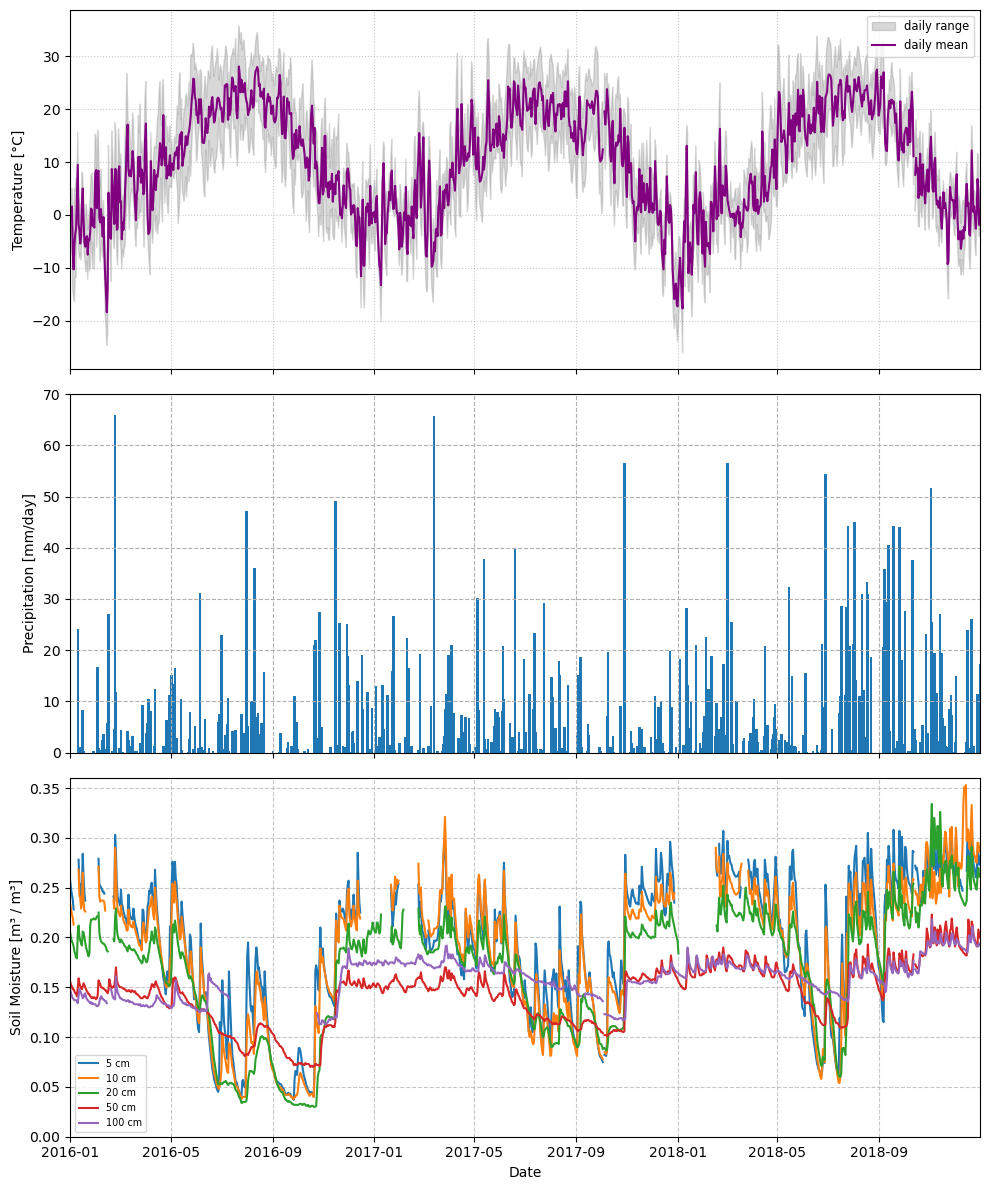

In [58]:
# Set up figure with 3 stacked subplots
# sharex=True ensures the dates align across all three
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

# Temperature
# Daily range shaded in gray
ax1.fill_between(date, t_daily_min, t_daily_max, color='gray', alpha=0.3, label='daily range')
# Daily mean line in purple
ax1.plot(date, t_daily_mean, color='purple', label='daily mean')
ax1.set_ylabel('Temperature [°C]')
ax1.legend(loc='upper right', fontsize='small')
ax1.grid(True, linestyle=':', alpha=0.7)

# Precipitation
ax2.bar(date, p_daily_calc, width=3.0)
ax2.set_ylabel('Precipitation [mm/day]')
ax2.set_ylim(0, 70) 
ax2.grid(True, linestyle='dashed', alpha=1)

# Soil Moisture
sm_5_clean = np.where(soil_moisture_5 < 0, np.nan, soil_moisture_5)
ax3.plot(date, sm_5_clean, label='5 cm', color='tab:blue')
ax3.plot(date, soil_moisture_10, label='10 cm', color='tab:orange')
ax3.plot(date, soil_moisture_20, label='20 cm', color='tab:green')
ax3.plot(date, soil_moisture_50, label='50 cm', color='tab:red')
ax3.plot(date, soil_moisture_100, label='100 cm', color='tab:purple')
ax3.set_ylabel('Soil Moisture [m³ / m³]')
ax3.set_xlabel('Date')
ax3.legend(loc='lower left', fontsize='small')
ax3.grid(True, linestyle=':', alpha=0.6)

ax3.set_ylabel('Soil Moisture [m³ / m³]')
ax3.set_xlim(date[0], date[-1])
ax3.set_ylim(0, 0.36)
ax3.legend(loc='lower left', fontsize='x-small', ncol=1)
ax3.grid(True, linestyle='--', alpha=0.7)


plt.tight_layout()
plt.show()

### Problem 2: Contour Plots

In [68]:
# Now we will visualize some global temperature data from the NCEP-NCAR atmospheric reanalysis.

In [13]:
import xarray as xr
ds_url = 'http://iridl.ldeo.columbia.edu/SOURCES/.NOAA/.NCEP-NCAR/.CDAS-1/.MONTHLY/.Diagnostic/.surface/.temp/dods'
ds = xr.open_dataset(ds_url, decode_times=False)
ds

<xarray.Dataset> Size: 67MB
Dimensions:  (X: 192, T: 926, Y: 94)
Coordinates:
  * X        (X) float32 768B 0.0 1.875 3.75 5.625 ... 352.5 354.4 356.2 358.1
  * T        (T) float32 4kB -131.5 -130.5 -129.5 -128.5 ... 791.5 792.5 793.5
  * Y        (Y) float32 376B 88.54 86.65 84.75 82.85 ... -84.75 -86.65 -88.54
Data variables:
    temp     (T, Y, X) float32 67MB ...
Attributes:
    Conventions:  IRIDL

In [14]:
#########################################################
#### BELOW ARE THE VARIABLES YOU SHOULD USE IN THE PLOTS!
#### (numpy arrays) 
#### NO XARRAY ALLOWED!
#########################################################

temp = ds.temp[-1].values - 273.15
lon = ds.X.values
lat = ds.Y.values

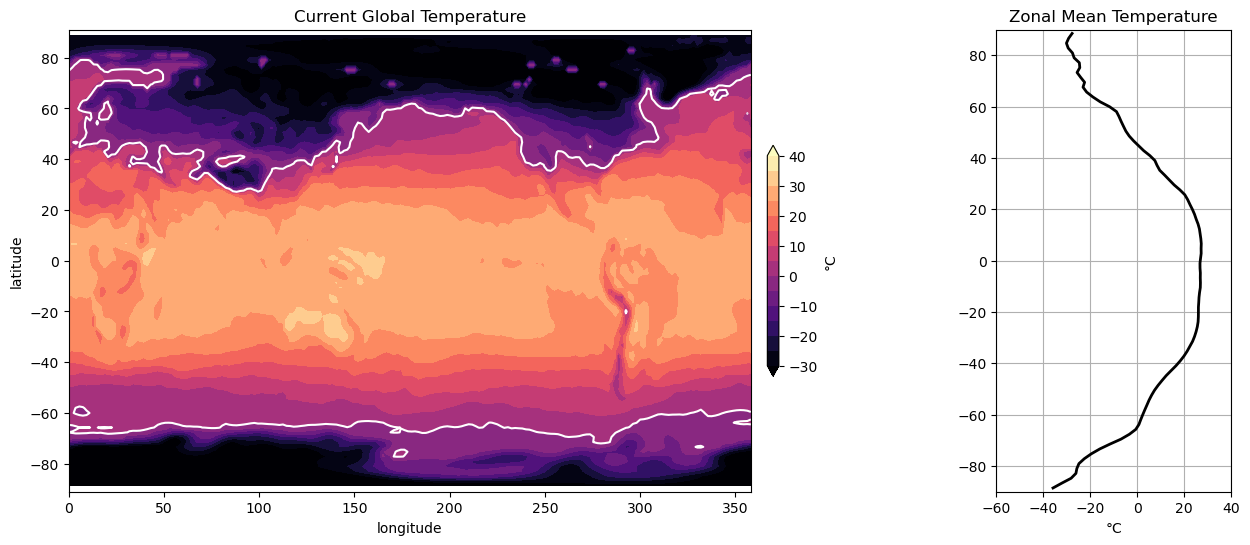

In [59]:

zonal_mean = np.mean(temp, axis=1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), 
                               gridspec_kw={'width_ratios': [3.5, 1]})

# first map plot
cf = ax1.contourf(lon, lat, temp, levels=np.arange(-30, 41, 5), cmap='magma', extend='both')
ax1.contour(lon, lat, temp, levels=[0], colors='white', linewidths=1.5)
ax1.set_title('Current Global Temperature')
ax1.set_xlabel('longitude')
ax1.set_ylabel('latitude')

# colorbar - linked to first plot ax1
plt.colorbar(cf, ax=ax1, label='°C', pad=0.02, shrink=0.5)

# zonal mean plot
ax2.plot(zonal_mean, lat, color='black', linewidth=2)
ax2.set_title('Zonal Mean Temperature')
ax2.set_xlabel('°C')
ax2.grid(True)

ax2.set_xlim(-60, 40)
ax2.set_xticks(np.arange(-60, 41, 20)) # Added 41 so 40 shows up


# match latitudes (-90 to 90 is gloabl tandard)
ax1.set_ylim(-91, 91)
ax1.set_yticks(np.arange(-80, 81, 20))
ax2.set_yticks(np.arange(-80, 81, 20))
ax2.set_ylim(-90, 90)

plt.show()

# Problem 3: Scatter plots

In [74]:
### Here we will make a map plot of earthquakes from a USGS catalog of historic large earthquakes. 
# Color the earthquakes by log10(depth) and adjust the marker size to be magntiude^4/100

In [28]:
fname = pooch.retrieve(
    "https://rabernat.github.io/research_computing/signif.txt.tsv.zip",
    known_hash='22b9f7045bf90fb99e14b95b24c81da3c52a0b4c79acf95d72fbe3a257001dbb',
    processor=pooch.Unzip()
)[0]

from matplotlib.colors import LogNorm

earthquakes = np.genfromtxt(fname, delimiter='\t')
depth = earthquakes[:, 8]
magnitude = earthquakes[:, 9]
latitude = earthquakes[:, 20]
longitude = earthquakes[:, 21]

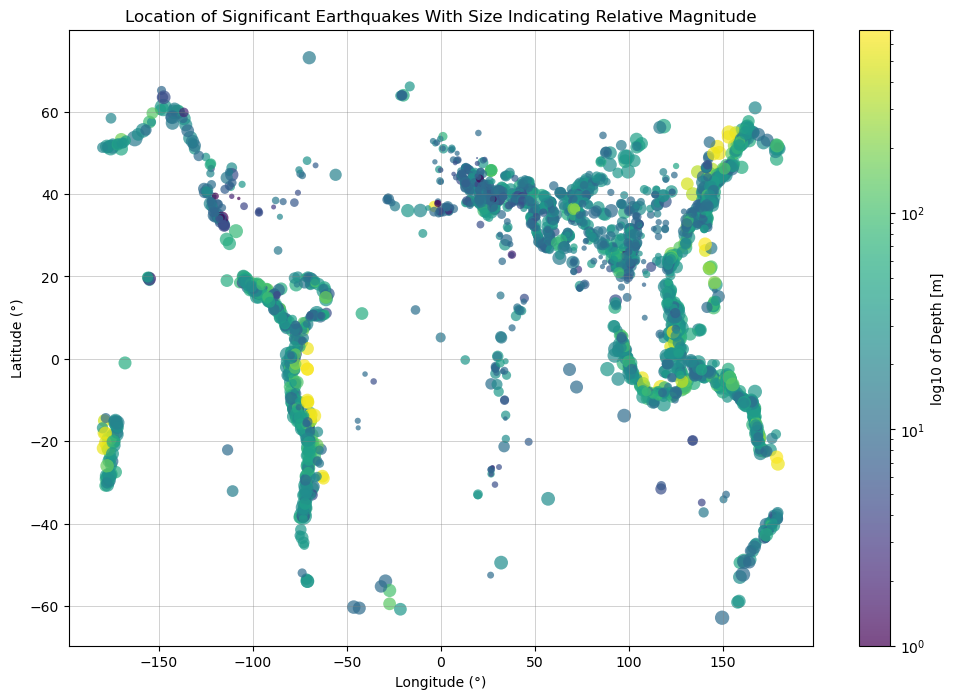

In [31]:
plt.figure(figsize=(12, 8))

# Experiment with (magnitude**3 / 10) or simply (magnitude * 5) ???
sc = plt.scatter(longitude, latitude, c=depth, s=magnitude**3 / 5, cmap='viridis', alpha=0.7, norm=LogNorm(vmin=1, vmax=700),edgecolors='none') 
# Removing edges makes it cleaner like the target

plt.colorbar(sc, label='log10 of Depth [m]')
plt.xlabel('Longitude (°)')
plt.ylabel('Latitude (°)')
plt.title('Location of Significant Earthquakes With Size Indicating Relative Magnitude')

plt.grid(True, color='gray', linestyle='-', linewidth=0.5, alpha=0.5)

plt.show()